In [1]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/home/tyumen/saiga_8b/saiga_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
texts_df = pd.read_csv('ru_cefr_short.csv')  
features_df = pd.read_csv('ru_cefr_short_linguistic_features.csv')  


if 'text' in features_df.columns:
    features_df = features_df.drop(columns=['text'])
if 'level_number' in features_df.columns:
    features_df = features_df.drop(columns=['level_number'])

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "ai-forever/ruBert-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)

print(f"Модель инициализирована")

Модель инициализирована


In [4]:
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            model_output = bert_model(**encoded)

        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

texts = texts_df['fragment'].fillna('').astype(str).tolist()
bert_embeddings = get_bert_embeddings(texts)
print(f"Размер BERT эмбеддингов: {bert_embeddings.shape}")

Размер BERT эмбеддингов: (7322, 1024)


In [5]:
X_numerical = features_df.values

X_combined = np.hstack([X_numerical, bert_embeddings])
print(f"Объединенные фичи: {X_combined.shape}")
print(f"Числовые фичи: {X_numerical.shape[1]}, BERT эмбеддинги: {bert_embeddings.shape[1]}")

Объединенные фичи: (7322, 1145)
Числовые фичи: 121, BERT эмбеддинги: 1024


# Классификация

In [6]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [7]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [8]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [9]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [10]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [11]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.644369,0.644369,0.562848,0.637154,0.447782
1,3,CatBoost Classifier,0.617065,0.617065,0.535493,0.611095,0.482594
2,8,LightGBM,0.612287,0.612287,0.536023,0.605697,0.490102
3,7,XGBoost,0.608874,0.608874,0.542171,0.603308,0.491468
4,5,K-Nearest Neighbors,0.569966,0.569966,0.539305,0.563693,0.644369
5,0,Logistic Regression,0.539932,0.539932,0.510457,0.540064,0.617747
6,2,Random Forest,0.547440,0.547440,0.454643,0.534310,0.580205
7,1,Decision Tree,0.405461,0.405461,0.371739,0.407028,0.846416
8,6,Naive Bayes,0.300341,0.300341,0.286951,0.293837,1.261433


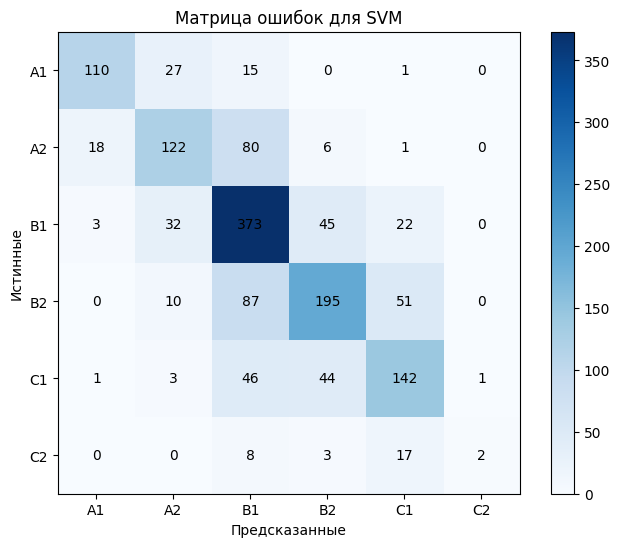

In [12]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [13]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [14]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [15]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [16]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.670307,0.670307,0.672599,0.668063,0.409556
1,3,CatBoost Classifier,0.645734,0.645734,0.653869,0.644283,0.438908
2,7,XGBoost,0.625939,0.625939,0.634694,0.624476,0.469625
3,8,LightGBM,0.621843,0.621843,0.625576,0.620182,0.463481
4,5,K-Nearest Neighbors,0.582935,0.582935,0.580829,0.580288,0.605461
5,0,Logistic Regression,0.559727,0.559727,0.568244,0.559656,0.575427
6,2,Random Forest,0.556997,0.556997,0.549031,0.549368,0.559727
7,1,Decision Tree,0.425256,0.425256,0.432711,0.424882,0.800000
8,6,Naive Bayes,0.413652,0.413652,0.405208,0.383695,0.946758


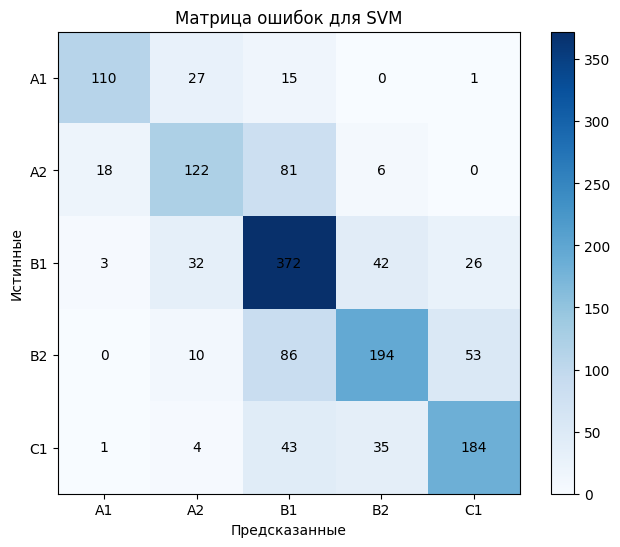

In [17]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [18]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    # ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [19]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [20]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [21]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [22]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [23]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.533106,0.533106,0.444607,0.527180,0.516041
1,2,CatBoost Regressor,0.531058,0.531058,0.445122,0.525495,0.529010
2,6,LightGBM,0.524915,0.524915,0.447481,0.520533,0.535154
3,4,K-Nearest Neighbors,0.510580,0.510580,0.464663,0.504380,0.592491
4,5,XGBoost,0.486007,0.486007,0.411796,0.482287,0.586348
5,0,Linear Regression,0.470990,0.470990,0.418729,0.471936,0.607509
6,1,Decision Tree,0.397952,0.397952,0.352977,0.399266,0.833447


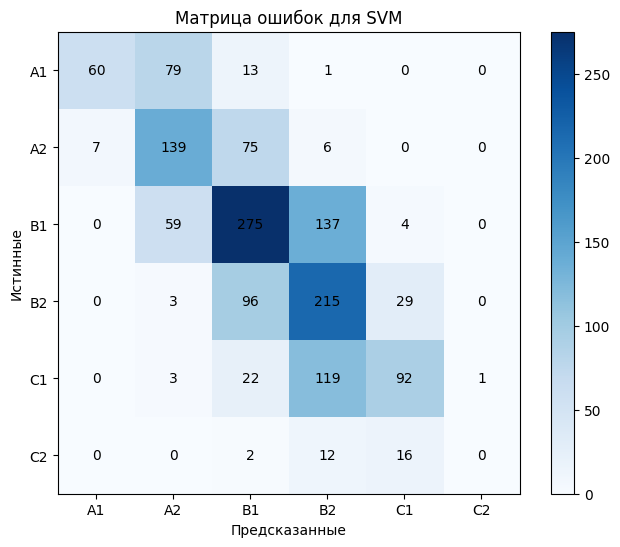

In [24]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [25]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [26]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.458020,0.458020,0.419712,0.451499,0.648464
1,1,Decision Tree,0.397952,0.397952,0.352977,0.399266,0.833447
2,0,Linear Regression,0.378840,0.378840,0.333062,0.378231,0.748123
3,3,SVM,0.397270,0.397270,0.332887,0.377874,0.688055
4,6,LightGBM,0.397270,0.397270,0.323950,0.376870,0.701024
5,5,XGBoost,0.391809,0.391809,0.309489,0.376101,0.721502
6,2,CatBoost Regressor,0.392491,0.392491,0.324994,0.373428,0.700341


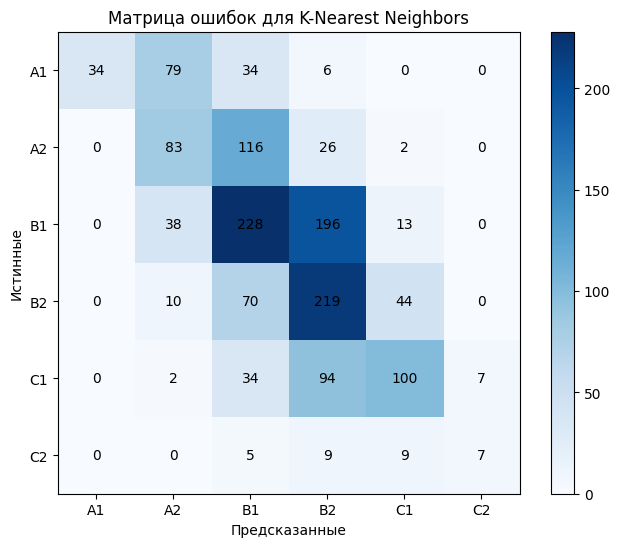

In [27]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [28]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [29]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.458703,0.458703,0.372663,0.425997,0.645051
1,2,CatBoost Regressor,0.451195,0.451195,0.359726,0.418985,0.651195
2,6,LightGBM,0.442321,0.442321,0.354380,0.411005,0.666212
3,0,Linear Regression,0.421160,0.421160,0.354139,0.405685,0.709215
4,5,XGBoost,0.423208,0.423208,0.353333,0.399535,0.694198
5,1,Decision Tree,0.397952,0.397952,0.352977,0.399266,0.833447
6,4,K-Nearest Neighbors,0.419113,0.419113,0.344906,0.389858,0.752218


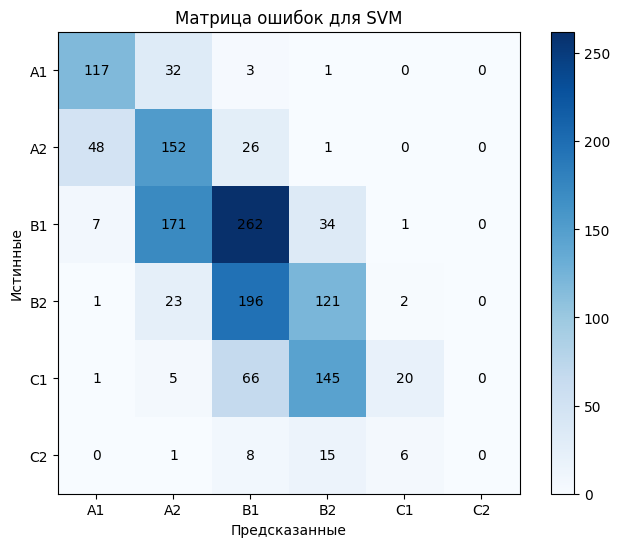

In [30]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [31]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [32]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [33]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [34]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [35]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.539932,0.539932,0.537554,0.539681,0.496928
1,2,CatBoost Regressor,0.533106,0.533106,0.522589,0.528444,0.505119
2,6,LightGBM,0.524915,0.524915,0.517208,0.521450,0.522867
3,4,K-Nearest Neighbors,0.516041,0.516041,0.513798,0.511141,0.574061
4,5,XGBoost,0.490785,0.490785,0.491168,0.492207,0.571331
5,0,Linear Regression,0.481229,0.481229,0.486388,0.484684,0.582253
6,1,Decision Tree,0.404778,0.404778,0.406132,0.405386,0.812969


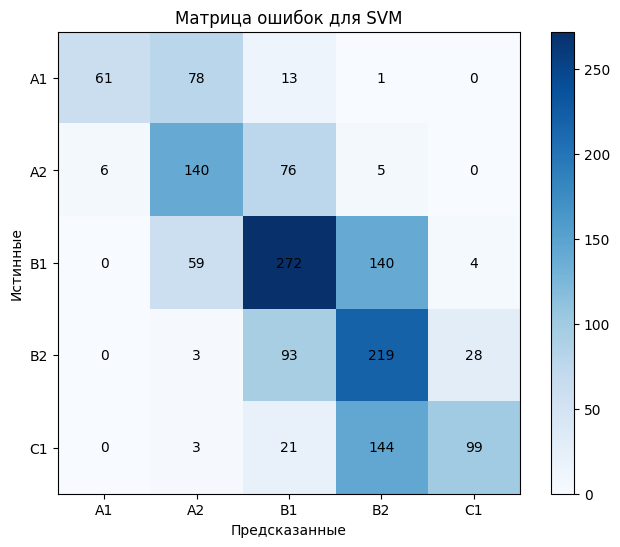

In [36]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [37]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [38]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.461433,0.461433,0.442294,0.457060,0.631399
1,0,Linear Regression,0.422526,0.422526,0.394153,0.408968,0.674403
2,1,Decision Tree,0.404778,0.404778,0.406132,0.405386,0.812969
3,3,SVM,0.425939,0.425939,0.381171,0.404418,0.649829
4,5,XGBoost,0.417065,0.417065,0.376772,0.400385,0.688055
5,2,CatBoost Regressor,0.415017,0.415017,0.370110,0.393520,0.670990
6,6,LightGBM,0.414334,0.414334,0.369983,0.391298,0.676451


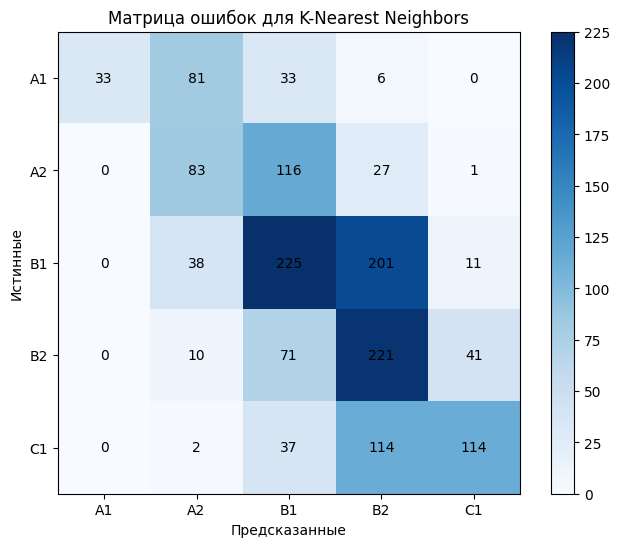

In [39]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [40]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [41]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,0,Linear Regression,0.436177,0.436177,0.439937,0.423725,0.674403
1,3,SVM,0.457338,0.457338,0.440947,0.423460,0.625256
2,6,LightGBM,0.449147,0.449147,0.421328,0.410848,0.639590
3,2,CatBoost Regressor,0.444369,0.444369,0.415452,0.406767,0.642321
4,1,Decision Tree,0.404778,0.404778,0.406132,0.405386,0.812969
5,5,XGBoost,0.427304,0.427304,0.411777,0.400068,0.683959
6,4,K-Nearest Neighbors,0.423208,0.423208,0.403525,0.393938,0.736519


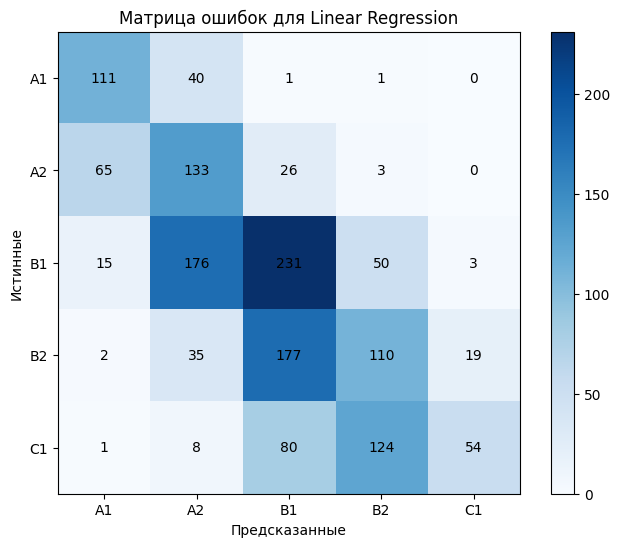

In [42]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()